<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [1]:
install.packages("glmnet")


Installing package into 'C:/Users/luzsa/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependencies 'iterators', 'foreach', 'shape'




package 'iterators' successfully unpacked and MD5 sums checked
package 'foreach' successfully unpacked and MD5 sums checked
package 'shape' successfully unpacked and MD5 sums checked
package 'glmnet' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\luzsa\AppData\Local\Temp\RtmpYL5yf1\downloaded_packages


In [2]:
library(glmnet)
library(tidyverse)
library(ggplot2)

Warning message:
"package 'glmnet' was built under R version 4.5.3"
Loading required package: Matrix

Loaded glmnet 4.1-10

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [41]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [42]:
# Train-test split 
train =  sample(1:n, 50) #Random selection
test = (1:n)[-train]


In [43]:
#Train-test dataframe
train_df <- data.frame(x = x[train], y = y[train])
test_df <-  data.frame(x = x[test], y = y[test])


(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

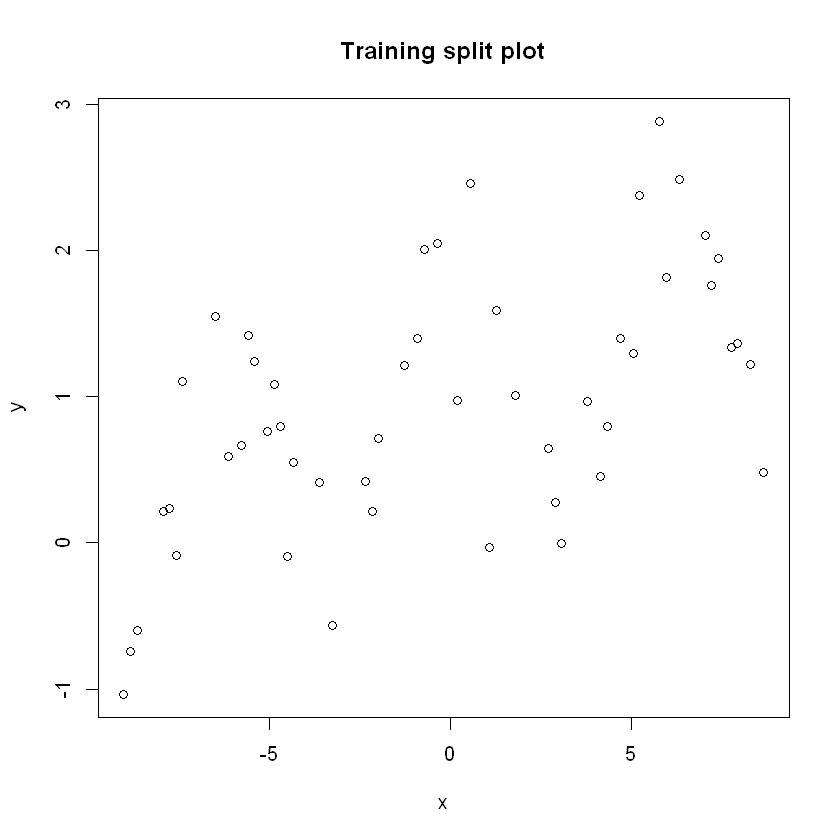

In [44]:
#Training data plot 
plot(train_df$x, train_df$y,
     main= "Training split plot",
    xlab = "x",
    ylab = "y")


How would you describe the relationship between $x$ and $y$ based on this plot?

> I dont see a strong relationship between x and y, the data appers to be noisy with a random scatter showing a minimal relationship.

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

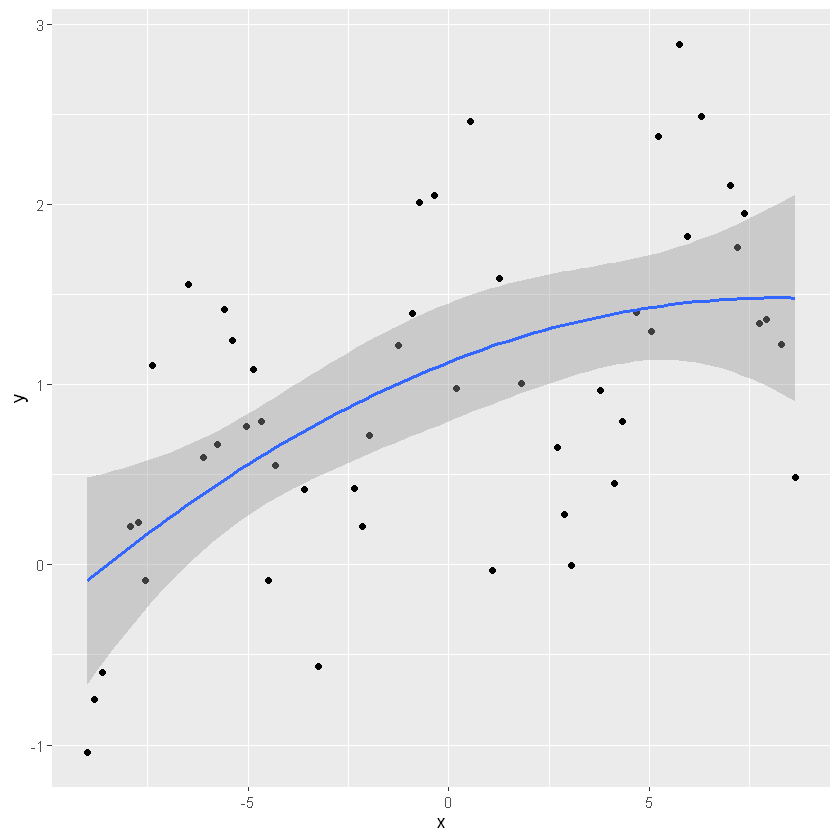

In [45]:
#Plotting the 2nd degree polynomial
ggplot(train_df, aes(x = x, y = y)) +
  geom_point() +
  geom_smooth(method = "lm", formula = y ~ poly(x, 2)) 

How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> WIth the model fit we are stoarting to see a positive trend and relationship between x and y but there is still some variability and noise. I do think we can tighten this model further to account for this variability.
>

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

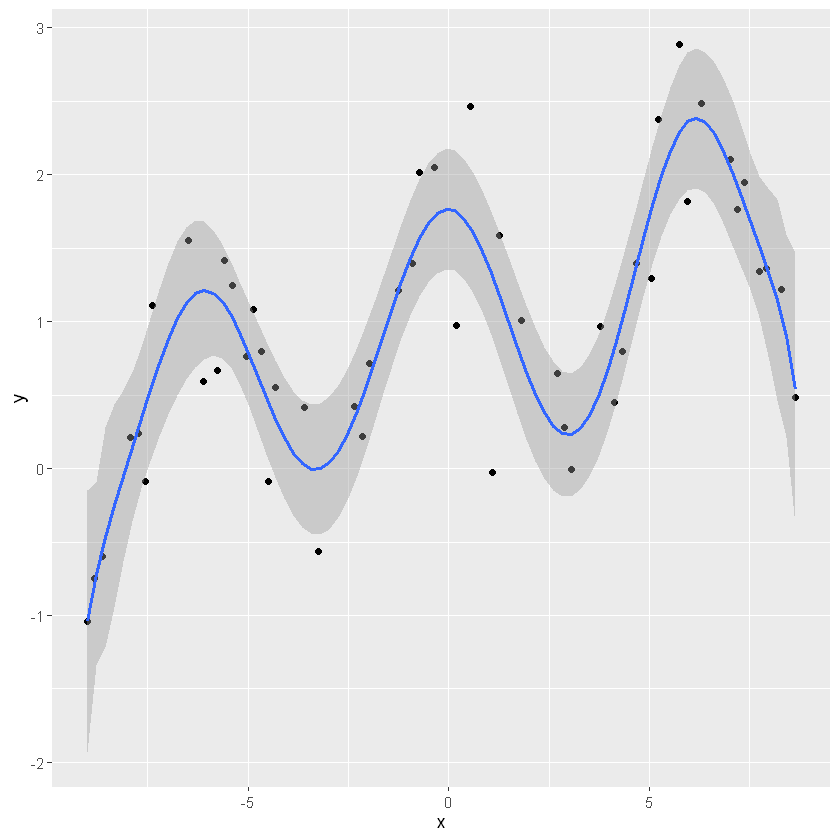

In [46]:
# 12th degree polynomial

ggplot(train_df, aes(x = x, y = y)) +
  geom_point() +
  geom_smooth(method = "lm", formula = y ~ poly(x, 12)) 

> With a higher degree polynomial - now there is an overcompensation of model fit where it also captures even random noise rather than capturing the overal trend.

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

In [47]:
length(unique(train_df$x))

[1] 50

In [48]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,49)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {

   
    #if (k >= nrow(train_df)) next  # skip if degree too high
    model <- lm(y ~ poly(x, k), data = train_df)

    #training err
    train_pred <- predict(model, newdata = train_df)
    train_rss[k-1] <- median((train_df$y - train_pred)^2)
    #testing err
    test_pred <- predict(model, newdata = test_df)
    test_rss[k-1] <- median((test_df$y - test_pred)^2)
}


# Plot your results here
plot(degree, train_rss,
     type = "l")


ERROR: Error in poly(x, k): 'degree' must be less than number of unique points


What do you see as $k$ increase?

> 
>

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



In [ ]:
# WRITE YOUR CODE HERE



What do you see as $k$ gets larger than $n$?

> *Write your response here*
>

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

In [51]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    x_train <- model.matrix(~ poly(x, k), data = train_df)[,-1]
    x_test  <- model.matrix(~ poly(x, k), data = test_df)[,-1]
    model <- glmnet(x_train, train_df$y, alpha=0, lambda=lambda)

    
    train_pred <- predict(model, newx=x_train, s=lambda)
    train_rss[k-1] <- median((train_df$y - train_pred)^2)
  

    test_pred <- predict(model, newx=x_test, s=lambda)
    test_rss[k-1] <- median((test_df$y - test_pred)^2)
}
# Plot your results here

plot(degree, train_rss,
     type = "l")

ERROR: Error in poly(x, k): 'degree' must be less than number of unique points


What happens now when $k$ gets larger than $n$?

> With a ridge regression - still works well 
>

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> as the the lambda penalty shrinks the coefficients, preventing the model from overfitting to noise in the training data.

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

>  The regularization works around this by adding the lambda penalty, which shrinks coefficients toward zero and ensures a stable solution.

**DUE:** 5pm EST, April 7, 2026